In [488]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [490]:
np.random.seed(42)

In [494]:
balls_faced=np.random.randint(20,100,size=20)

In [496]:
balls_faced

array([77, 41, 68, 78, 61, 79, 99, 34, 81, 81, 66, 81, 70, 74, 83, 22, 70,
       26, 40, 92])

In [498]:
true_strike_rate=0.8

In [500]:
boundaries=np.random.randint(0,10,size=20)

In [502]:
boundaries

array([6, 1, 3, 8, 1, 9, 8, 9, 4, 1, 3, 6, 7, 2, 0, 3, 1, 7, 3, 1])

In [504]:
runs=(0.6*balls_faced+3.5*boundaries+5+noise).round().astype(int)

In [506]:
runs

array([72, 31, 54, 79, 46, 80, 93, 57, 73, 57, 52, 84, 61, 62, 59, 23, 56,
       47, 38, 58])

In [508]:
noise=np.random.normal(0,5,size=20)

In [510]:
noise

array([-6.88969652, -1.76558326, -2.30732859,  0.33328639, -0.88142831,
        6.00446386,  3.49199471, -0.85814418, -4.5359329 ,  5.94312863,
        3.92766062, 13.28005046,  1.3174302 ,  8.20885558,  2.3040815 ,
        0.42961736, -7.54978641,  3.60751231, -4.21709962, -2.56662703])

In [512]:
runs_scored=(true_strike_rate*balls_faced+noise).round().astype(int)

In [514]:
runs_scored

array([55, 31, 52, 63, 48, 69, 83, 26, 60, 71, 57, 78, 57, 67, 69, 18, 48,
       24, 28, 71])

In [516]:
data=pd.DataFrame({"Innings":np.arange(1,21),
                  "Balls_Faced":balls_faced,
                  "Runs_Scored":runs_scored,
                  "Boundaries":boundaries})

In [518]:
data

,Innings,Balls_Faced,Runs_Scored,Boundaries
0,1,77,55,6
1,2,41,31,1
2,3,68,52,3
3,4,78,63,8
4,5,61,48,1
5,6,79,69,9
6,7,99,83,8
7,8,34,26,9
8,9,81,60,4
9,10,81,71,1


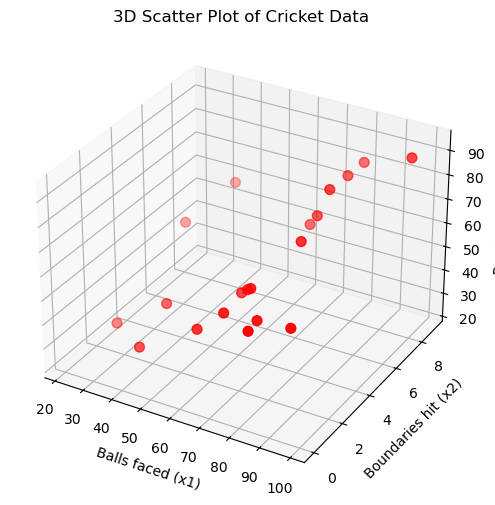

In [520]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(balls_faced,boundaries,runs, c='red',marker='o',s=50)
ax.set_xlabel("Balls faced (x1)")
ax.set_ylabel("Boundaries hit (x2)")
ax.set_zlabel("Runs scored (y)")
ax.set_title("3D Scatter Plot of Cricket Data")
plt.show()

In [ ]:
display(data)

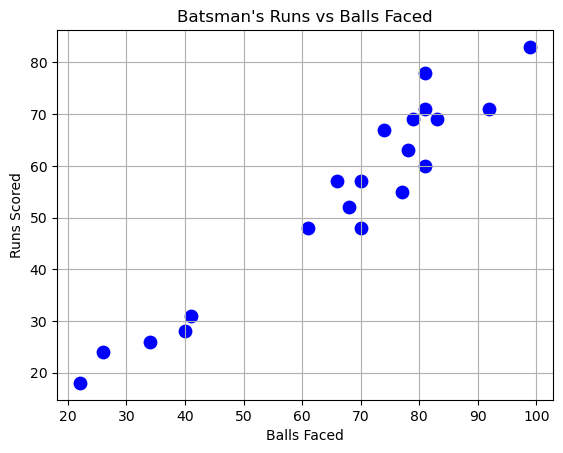

In [522]:
plt.scatter(balls_faced,runs_scored,color="blue",s=80)
plt.xlabel("Balls Faced")
plt.ylabel("Runs Scored")
plt.title("Batsman's Runs vs Balls Faced")
plt.grid(True)
plt.show()

In [608]:
def grads(w0,w1,x,y): # this function calculates the gradients i.e., partial derivatives w.r.t. w1 and w0
    m=len(x)
    grad1 = (-2/m)*np.sum((y- w1*x - w0)*x)  
    grad0 = (-2/m)*np.sum(y- w1*x - w0)
    return grad0, grad1
def update(w0,w1,grad0,grad1,gamma): # equation of gradient descent w1= w1-gamma* grad1
    w1 = w1 - gamma*grad1
    w0 = w0 - gamma*grad0
    return w0, w1
def Loss(w0,w1,x,y): # loss function in terms of error square
    total_error = np.sum((y- w1*x - w0)**2)
    return total_error

In [610]:
#-- intialization
w0 = 1    # random intilization of weights
w1 = 1
y = runs_scored
x = balls_faced

In [612]:
y

array([55, 31, 52, 63, 48, 69, 83, 26, 60, 71, 57, 78, 57, 67, 69, 18, 48,
       24, 28, 71])

In [614]:
x

array([77, 41, 68, 78, 61, 79, 99, 34, 81, 81, 66, 81, 70, 74, 83, 22, 70,
       26, 40, 92])

In [616]:
gamma = 0.00001 # learing rate


Gradients are 0.9152089079849102 and 24.16814281517127
Loss is 509.127204276945


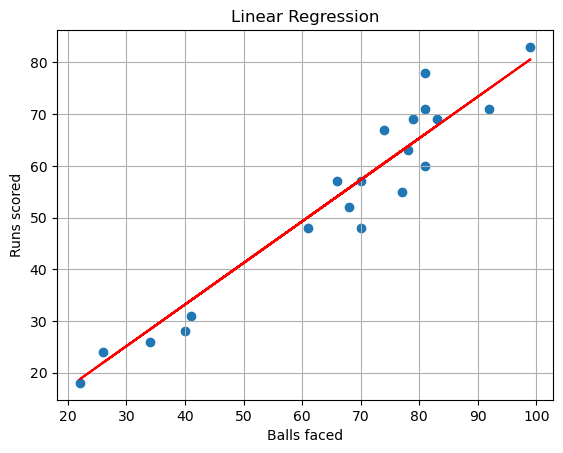

In [704]:
grad0, grad1 = grads(w0,w1,x,y)
print("Gradients are " + str(grad0) +  " and " +  str(grad1))
w0, w1 = update(w0,w1,grad0,grad1,gamma)
loss = Loss(w0,w1,x,y)
print("Loss is " + str(loss))
plt.title("Linear Regression")
plt.xlabel("Balls faced")
plt.ylabel("Runs scored")
plt.scatter(x,y)
plt.plot(x, w1*x+w0, 'r')
plt.grid()
plt.show()

In [706]:
def predict(w0,w1,test):
    pred=w1*test+w0
    return pred
test=25
pred=predict(w0,w1,test)
print("The predicted value is  " +str(pred))

The predicted value is  21.100821099174702
